####  imports & settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
pd.set_option('display.max_columns', None)
%matplotlib inline


####  load dataset

In [2]:
df = pd.read_csv('loan.csv')


#### Quick checks

In [3]:
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.head(3))


Shape: (614, 13)
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
    Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   
2  LP001005   Male     Yes          0  Graduate           Yes   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0         Urban           Y  


#### feature engineering - total income and missing counts

In [4]:
if 'ApplicantIncome' in df.columns and 'CoapplicantIncome' in df.columns:
    df['Total_Income'] = df['ApplicantIncome'].fillna(0) + df['CoapplicantIncome'].fillna(0)
print(df.isnull().sum().sort_values(ascending=False).head(20))


Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Loan_ID               0
Education             0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
Total_Income          0
dtype: int64


#### prepare target and drop identifiers if present

In [5]:
target_col = 'Loan_Status'
if target_col in df.columns:
    df = df.copy()
    df[target_col] = df[target_col].map({'Y':1, 'N':0})  # adjust mapping if needed
else:
    raise ValueError("Expected column 'Loan_Status' in dataset.")
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)


#### separate X and y, identify numeric & categorical columns

In [6]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
# Ensure Total_Income (if created) is numeric
num_cols = [c for c in num_cols if c in X.columns]
cat_cols = [c for c in cat_cols if c in X.columns]
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Total_Income']
Categorical cols: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


#### simple imputation & encoding for categorical, median impute + scaler for numeric

In [7]:
# Numeric pipeline (median impute + scale)
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols, index=X.index)
X_num = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols, index=X.index)

# Categorical: fill with mode then one-hot encode (drop_first to avoid multicollinearity)
X_cat = X[cat_cols].copy()
for c in cat_cols:
    X_cat[c] = X_cat[c].fillna(X_cat[c].mode().iloc[0])
X_cat = pd.get_dummies(X_cat, drop_first=True)

# Combined processed features
X_processed = pd.concat([X_num, X_cat], axis=1)
print("Processed shape:", X_processed.shape)


Processed shape: (614, 15)


#### train/test split (stratify on target)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True))


Train shape: (491, 15) Test shape: (123, 15)
Train class distribution:
 Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


#### Logistic Regression baseline

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1:", f1_score(y_test, y_pred_lr, zero_division=0))
print(classification_report(y_test, y_pred_lr, zero_division=0))


Logistic Regression metrics:
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1: 0.9081081081081082
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



#### Random Forest with GridSearch (simple grid)

In [10]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Best RF params:", grid.best_params_)
print("Random Forest metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rf, zero_division=0))
print(classification_report(y_test, y_pred_rf, zero_division=0))


Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest metrics:
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1: 0.9081081081081082
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



#### confusion matrix plot for the best RF model

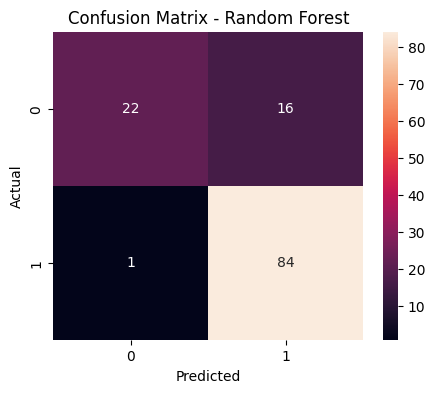

In [11]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### feature importances (top 20) and save model

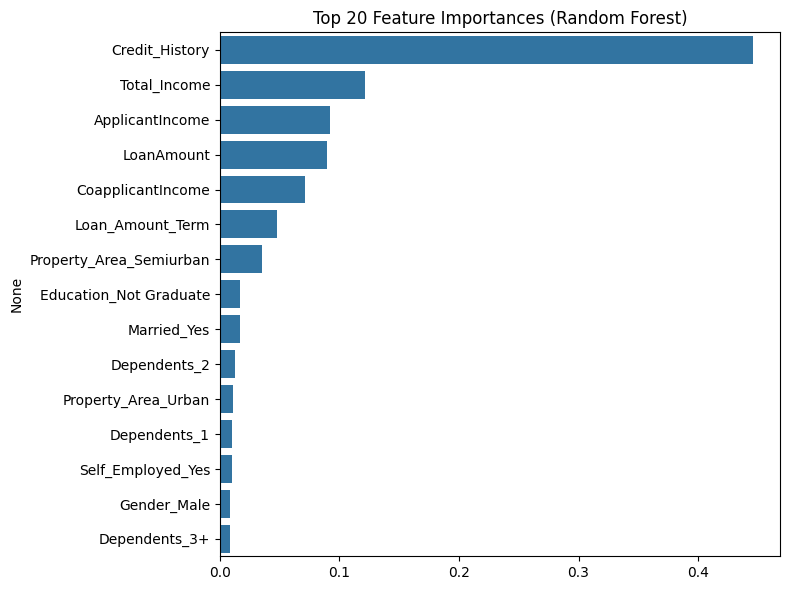

Saved Random Forest model to loan_rf_model.joblib


In [12]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top20 = importances.head(20)
plt.figure(figsize=(8,6))
sns.barplot(x=top20.values, y=top20.index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

joblib.dump(best_rf, 'loan_rf_model.joblib')
print("Saved Random Forest model to loan_rf_model.joblib")
